# AI-Driven Retail Intelligence and Smart Inventory Optimization Platform

## Project Overview

Retail businesses often face challenges in maintaining optimal inventory levels due to changing customer demand, seasonal trends, and market fluctuations. Poor inventory planning can result in overstocking, increased storage costs, or understocking, leading to customer dissatisfaction and revenue loss.

This project aims to develop an AI-driven retail intelligence system capable of forecasting product demand and optimizing inventory decisions using Machine Learning and Deep Learning techniques. The system analyzes historical retail sales data to identify trends, predict future demand, detect stock-related risks, and provide intelligent inventory recommendations.

The project utilizes Machine Learning algorithms such as Random Forest and XGBoost, along with Deep Learning techniques like LSTM (Long Short-Term Memory) for time-series demand forecasting.

## Importing Required Libraries

In this step, necessary Python libraries are imported for data manipulation, visualization, machine learning, and deep learning tasks.

- **Pandas** → Data handling and preprocessing  
- **NumPy** → Numerical computations  
- **Matplotlib & Seaborn** → Data visualization  
- **Scikit-Learn** → Machine Learning models  
- **TensorFlow/Keras** → Deep Learning (LSTM)

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


## Loading the Dataset

The retail inventory dataset is loaded into the Google Colab environment for analysis. The dataset contains historical retail sales data including inventory levels, product categories, pricing, seasonal information, promotions, and demand-related attributes.

In [ ]:
# Load Dataset

df = pd.read_csv('/content/retail_store_inventory.csv')

# Display first 5 rows
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Understanding the Dataset

Before performing analysis and model building, it is important to understand the dataset structure, dimensions, data types, and feature availability.

This step helps identify:
- Number of rows and columns
- Feature names
- Data types
- Missing values
- Overall dataset characteristics

In [ ]:
# Shape of Dataset

print("Dataset Shape:", df.shape)

Dataset Shape: (73100, 15)


### Observation

The dataset shape represents the number of rows and columns present in the dataset. A larger dataset helps improve model training and prediction reliability.

In [ ]:
# Display Columns

print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')


### Observation

The dataset contains multiple features related to inventory, pricing, product categories, promotions, seasonality, and demand forecasting, which are useful for retail demand prediction.

In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

### Observation

The dataset information provides details regarding data types, memory usage, and null values. This step helps identify categorical and numerical features required for preprocessing.

In [ ]:
# Statistical Summary

df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


### Observation

The statistical summary provides insights into numerical features including mean, minimum, maximum, and standard deviation. It helps understand feature distribution and possible outliers.

In [ ]:
# Missing Values Check

df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


### Observation

Checking missing values is an important preprocessing step to ensure data quality before applying Machine Learning and Deep Learning models.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the underlying structure of the dataset, identify patterns, detect anomalies, and visualize relationships between different variables.

This step helps in:
- Understanding sales trends
- Analyzing product performance
- Identifying seasonal patterns
- Understanding the impact of pricing and inventory
- Preparing data for Machine Learning and Deep Learning models

In [ ]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

## Distribution of Units Sold

This visualization helps understand how product sales are distributed across the dataset and whether sales follow a normal or skewed distribution.

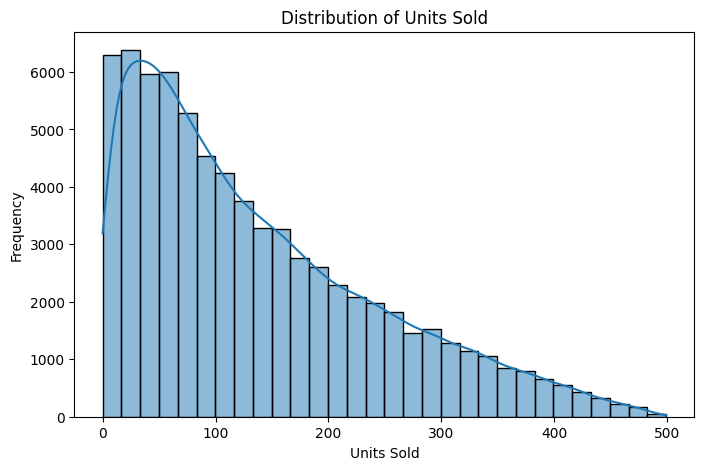

In [ ]:
# Distribution of Units Sold

plt.figure(figsize=(8,5))
sns.histplot(df['Units Sold'], bins=30, kde=True)

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

### Observation

The distribution graph helps analyze sales frequency and identify whether product demand is evenly distributed or concentrated in specific ranges.

## Category-wise Sales Analysis

This visualization helps identify which product categories contribute more to sales and demand.

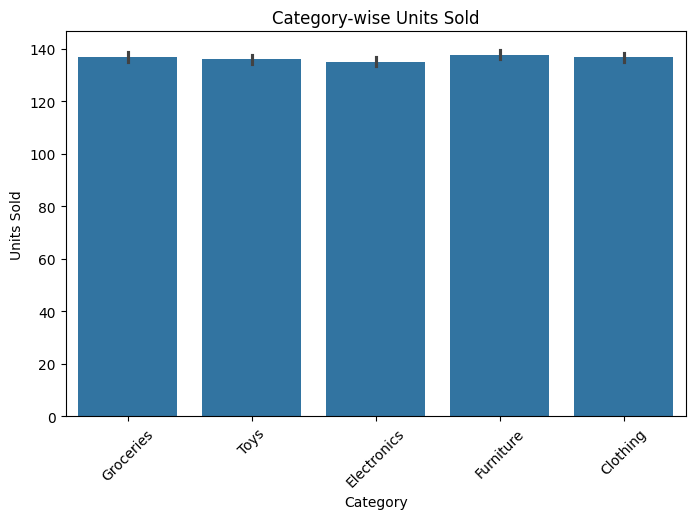

In [ ]:
# Category-wise Average Sales

plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Units Sold',
    data=df
)

plt.title('Category-wise Units Sold')
plt.xlabel('Category')
plt.ylabel('Units Sold')

plt.xticks(rotation=45)

plt.show()

### Observation

Different product categories show varying sales patterns. This analysis helps identify high-demand product categories and their contribution to retail sales.

## Region-wise Sales Analysis

This analysis helps understand how sales vary across different geographical regions.

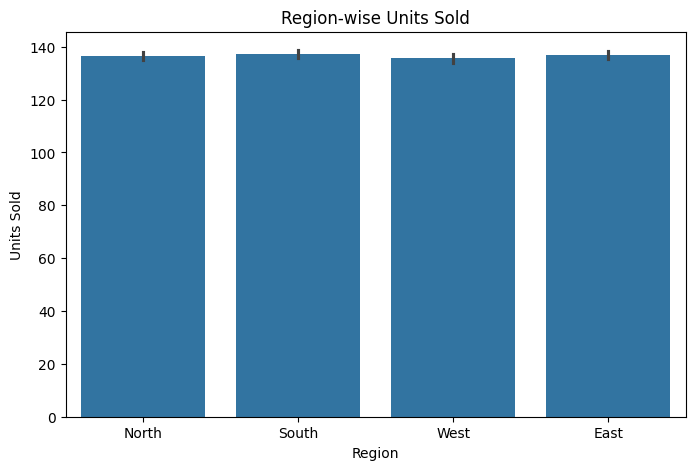

In [ ]:
# Region-wise Sales

plt.figure(figsize=(8,5))

sns.barplot(
    x='Region',
    y='Units Sold',
    data=df
)

plt.title('Region-wise Units Sold')
plt.xlabel('Region')
plt.ylabel('Units Sold')

plt.show()

### Observation

Sales performance varies across different regions, indicating possible differences in customer demand, demographics, and purchasing behavior.

## Inventory Level vs Units Sold

This scatter plot helps understand the relationship between available stock and product sales.

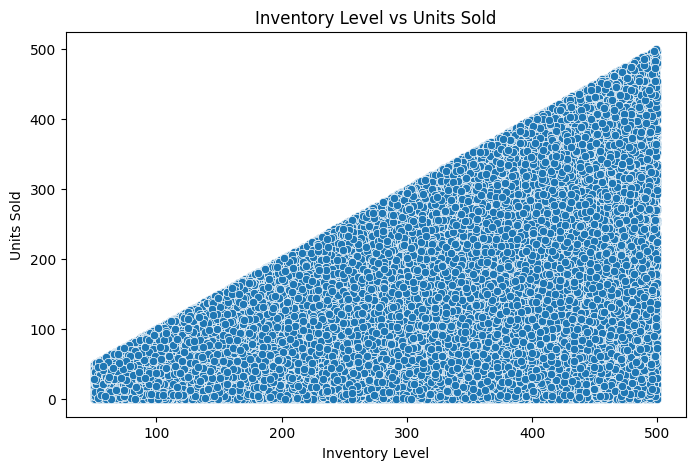

In [ ]:
# Inventory vs Units Sold

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Inventory Level',
    y='Units Sold',
    data=df
)

plt.title('Inventory Level vs Units Sold')
plt.xlabel('Inventory Level')
plt.ylabel('Units Sold')

plt.show()

### Observation

This plot helps analyze whether inventory levels influence product sales and identifies any visible trends or patterns.

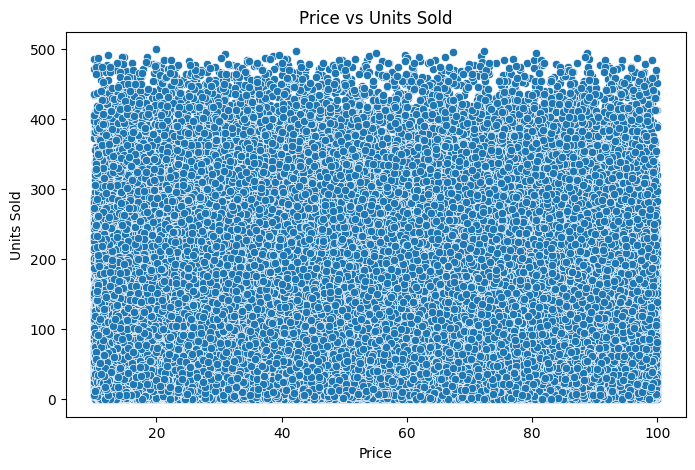

In [ ]:
# Price vs Units Sold

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Price',
    y='Units Sold',
    data=df
)

plt.title('Price vs Units Sold')
plt.xlabel('Price')
plt.ylabel('Units Sold')

plt.show()

### Observation

This analysis helps understand whether product pricing impacts sales demand and customer purchasing behavior.

## Correlation Matrix

A correlation matrix is used to understand relationships between numerical variables and identify features that strongly influence product demand.

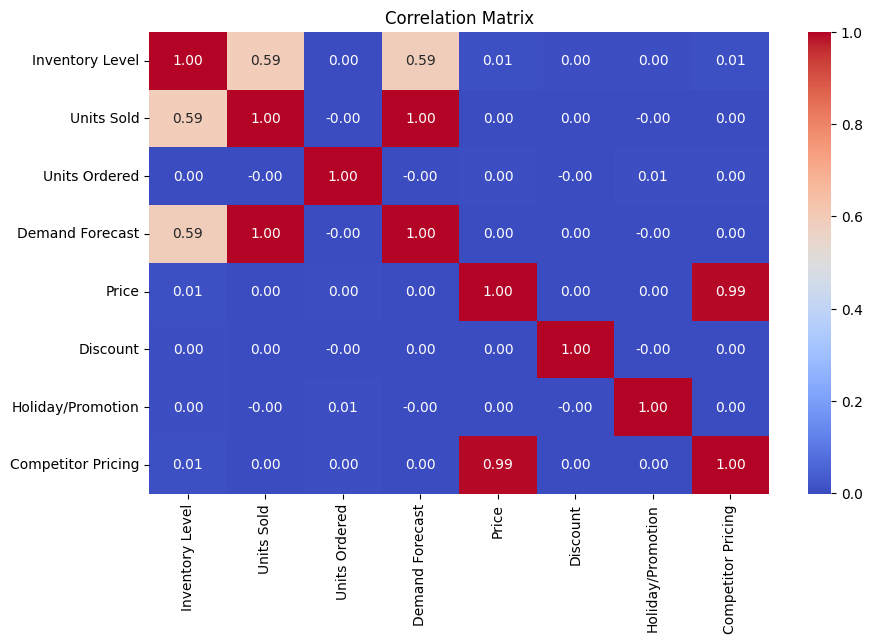

In [ ]:
# Correlation Matrix

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

### Observation

The correlation matrix helps identify strong positive and negative relationships between numerical variables. Features with higher correlation may significantly influence demand forecasting.

## Sales Trend Over Time

Time-series analysis helps visualize how product demand changes over time and identifies seasonal or trend-based patterns.

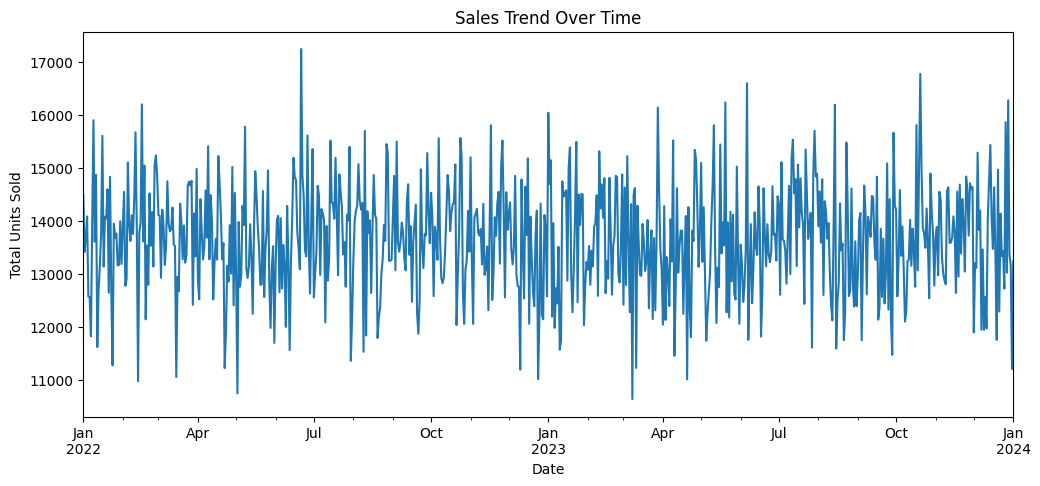

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dropna(subset=['Date'], inplace=True)

# Sales Trend

daily_sales = df.groupby('Date')['Units Sold'].sum()

plt.figure(figsize=(12,5))

daily_sales.plot()

plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')

plt.show()

### Observation

The sales trend visualization helps identify seasonal demand fluctuations and time-based sales patterns, which are important for time-series forecasting using LSTM.

# Feature Engineering and Data Preprocessing

Before applying Machine Learning and Deep Learning models, the dataset needs to be transformed into a suitable format.

This step includes:
- Handling categorical variables
- Converting date features
- Feature encoding
- Selecting input and target variables
- Data scaling
- Train-test splitting

In [ ]:
# Missing Values Check

df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0
Price,0


### Observation

The dataset is checked for missing values before preprocessing to ensure clean and reliable model training.

## Feature Engineering

The date column is transformed into meaningful time-based features to help Machine Learning models identify temporal sales patterns.

In [ ]:
# Extract Date Features

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1,1,5
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1,1,5
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1,1,5
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1,1,5
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1,1,5


In [ ]:
# Drop unnecessary columns

df = df.drop(columns=['Demand Forecast'])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,33.50,20,Rainy,0,29.69,Autumn,2022,1,1,5
1,2022-01-01,S001,P0002,Toys,South,204,150,66,63.01,20,Sunny,0,66.16,Autumn,2022,1,1,5
2,2022-01-01,S001,P0003,Toys,West,102,65,51,27.99,10,Sunny,1,31.32,Summer,2022,1,1,5
3,2022-01-01,S001,P0004,Toys,North,469,61,164,32.72,10,Cloudy,1,34.74,Autumn,2022,1,1,5
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,73.64,0,Sunny,0,68.95,Summer,2022,1,1,5


## Encoding Categorical Variables

Machine Learning models cannot directly process text-based categorical values. Therefore, categorical features are converted into numerical representations using label encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

categorical_columns = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Seasonality'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5
1,2022-01-01,0,1,4,2,204,150,66,63.01,20,3,0,66.16,0,2022,1,1,5
2,2022-01-01,0,2,4,3,102,65,51,27.99,10,3,1,31.32,2,2022,1,1,5
3,2022-01-01,0,3,4,1,469,61,164,32.72,10,0,1,34.74,0,2022,1,1,5
4,2022-01-01,0,4,1,0,166,14,135,73.64,0,3,0,68.95,2,2022,1,1,5


In [ ]:
# The 'Holiday/Promotion' column is already in a numerical format (0.0 and 1.0).
# The previous mapping incorrectly converted these to NaN values.
# Therefore, no conversion is needed for this column.

## Feature Selection

The input variables (features) and output variable (target) are selected for training the Machine Learning models.

Target Variable:
- Units Sold

In [ ]:
X = df.drop(
    columns=[
        'Units Sold',
        'Date',
        'Demand Forecast'
    ],
    errors='ignore'
)

y = df['Units Sold']

# Advanced Feature Engineering

Advanced feature engineering techniques are applied to improve model performance by extracting meaningful patterns from retail sales data.

This step includes:
- Time-based features
- Price-related features
- Sales trend features
- Forecasting features

In [ ]:
# Weekend Feature

df['IsWeekend'] = df['DayOfWeek'].apply(
    lambda x: 1 if x >= 5 else 0
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1
1,2022-01-01,0,1,4,2,204,150,66,63.01,20,3,0,66.16,0,2022,1,1,5,1
2,2022-01-01,0,2,4,3,102,65,51,27.99,10,3,1,31.32,2,2022,1,1,5,1
3,2022-01-01,0,3,4,1,469,61,164,32.72,10,0,1,34.74,0,2022,1,1,5,1
4,2022-01-01,0,4,1,0,166,14,135,73.64,0,3,0,68.95,2,2022,1,1,5,1


In [ ]:
# Price Competition Feature

df['PriceCompetitorRatio'] = (
    df['Price']
    /
    (df['Competitor Pricing'] + 1)
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,1.091561
1,2022-01-01,0,1,4,2,204,150,66,63.01,20,3,0,66.16,0,2022,1,1,5,1,0.938207
2,2022-01-01,0,2,4,3,102,65,51,27.99,10,3,1,31.32,2,2022,1,1,5,1,0.866027
3,2022-01-01,0,3,4,1,469,61,164,32.72,10,0,1,34.74,0,2022,1,1,5,1,0.915501
4,2022-01-01,0,4,1,0,166,14,135,73.64,0,3,0,68.95,2,2022,1,1,5,1,1.052752


In [ ]:
# Discount Impact Feature

df['DiscountEffect'] = (
    df['Price']
    *
    df['Discount']
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,1.091561,670.0
1,2022-01-01,0,1,4,2,204,150,66,63.01,20,3,0,66.16,0,2022,1,1,5,1,0.938207,1260.2
2,2022-01-01,0,2,4,3,102,65,51,27.99,10,3,1,31.32,2,2022,1,1,5,1,0.866027,279.9
3,2022-01-01,0,3,4,1,469,61,164,32.72,10,0,1,34.74,0,2022,1,1,5,1,0.915501,327.2
4,2022-01-01,0,4,1,0,166,14,135,73.64,0,3,0,68.95,2,2022,1,1,5,1,1.052752,0.0


In [ ]:
# Previous Sales Feature

df = df.sort_values('Date')

df['PreviousSales'] = (
    df.groupby('Product ID')['Units Sold']
    .shift(1)
)

df['PreviousSales'] = (
    df['PreviousSales']
    .fillna(df['PreviousSales'].median())
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales,RollingSalesMean
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,1.091561,670.0,107.0,127.000000
1,2022-01-01,0,1,4,2,204,150,66,63.01,20,3,0,66.16,0,2022,1,1,5,1,0.938207,1260.2,107.0,196.333333
2,2022-01-01,0,2,4,3,102,65,51,27.99,10,3,1,31.32,2,2022,1,1,5,1,0.866027,279.9,107.0,103.666667
3,2022-01-01,0,3,4,1,469,61,164,32.72,10,0,1,34.74,0,2022,1,1,5,1,0.915501,327.2,107.0,141.333333
4,2022-01-01,0,4,1,0,166,14,135,73.64,0,3,0,68.95,2,2022,1,1,5,1,1.052752,0.0,107.0,78.333333


In [ ]:
# Sort by Date

df = df.sort_values('Date')

# Previous Sales Feature

df['PreviousSales'] = (
    df.groupby('Product ID')['Units Sold']
    .shift(1)
)

# Fill Missing Values

df['PreviousSales'] = (
    df['PreviousSales']
    .fillna(
        df['PreviousSales'].median()
    )
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,1.091561,670.00,107.0
72,2022-01-01,3,12,2,0,191,56,65,61.81,0,3,0,63.92,0,2022,1,1,5,1,0.952095,0.00,107.0
71,2022-01-01,3,11,1,1,349,9,165,14.25,5,1,1,18.56,1,2022,1,1,5,1,0.728528,71.25,107.0
70,2022-01-01,3,10,1,3,205,46,27,54.84,0,3,1,57.76,1,2022,1,1,5,1,0.933288,0.00,107.0
69,2022-01-01,3,9,3,0,447,104,96,33.48,15,0,0,37.15,2,2022,1,1,5,1,0.877588,502.20,107.0


In [ ]:
# Rolling Sales Mean

df['RollingSalesMean'] = (
    df.groupby('Product ID')['Units Sold']
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=1
        ).mean()
    )
)

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales,RollingSalesMean
0,2022-01-01,0,0,3,1,231,127,55,33.50,20,1,0,29.69,0,2022,1,1,5,1,1.091561,670.00,107.0,127.0
72,2022-01-01,3,12,2,0,191,56,65,61.81,0,3,0,63.92,0,2022,1,1,5,1,0.952095,0.00,107.0,56.0
71,2022-01-01,3,11,1,1,349,9,165,14.25,5,1,1,18.56,1,2022,1,1,5,1,0.728528,71.25,107.0,9.0
70,2022-01-01,3,10,1,3,205,46,27,54.84,0,3,1,57.76,1,2022,1,1,5,1,0.933288,0.00,107.0,46.0
69,2022-01-01,3,9,3,0,447,104,96,33.48,15,0,0,37.15,2,2022,1,1,5,1,0.877588,502.20,107.0,104.0


In [ ]:
# Inventory Gap

df['InventoryGap'] = (
    df['Inventory Level']
    - df['PreviousSales']
)

In [ ]:
# Discount Competitor Ratio

df['DiscountCompetitorRatio'] = (
    df['Discount']
    /
    (df['Competitor Pricing'] + 1)
)

In [ ]:
# Order Fulfillment Ratio

df['OrderFulfillmentRatio'] = (
    df['Units Ordered']
    /
    (df['Inventory Level'] + 1)
)

In [ ]:
# Rolling Sales Mean 7

df['RollingSalesMean7'] = (
    df.groupby('Product ID')['Units Sold']
      .transform(
          lambda x: x.rolling(
              window=7,
              min_periods=1
          ).mean()
      )
)

In [ ]:
# Rolling Sales Max 7

df['RollingSalesMax7'] = (
    df.groupby('Product ID')['Units Sold']
      .transform(
          lambda x: x.rolling(
              window=7,
              min_periods=1
          ).max()
      )
)

In [ ]:
print(X.shape)

(73100, 28)


In [ ]:
print(df.columns)

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing',
       'Seasonality', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend',
       'PriceCompetitorRatio', 'DiscountEffect', 'PreviousSales',
       'RollingSalesMean', 'RollingSalesStd', 'InventoryCoverage',
       'InventoryGap', 'DiscountCompetitorRatio', 'OrderFulfillmentRatio',
       'RollingSalesMean7', 'RollingSalesMax7'],
      dtype='object')


In [ ]:
# Features and Target

X = df.drop(
    columns=[
        'Units Sold',
        'Date'
    ],
    errors='ignore'
)

y = df['Units Sold']

In [ ]:
from sklearn.model_selection import train_test_split

# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (58480, 28)
Testing Data: (14620, 28)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


# Machine Learning Model Building

Machine Learning models are trained to predict future product demand based on historical retail sales data.

In this section, multiple regression models are implemented to compare performance and identify the most suitable forecasting approach.

Models Used:
- Random Forest Regressor
- XGBoost Regressor

## Random Forest Regressor

Random Forest is an ensemble Machine Learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is widely used for regression problems and helps capture complex relationships between variables.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [40]:
# Predictions

rf_predictions = rf_model.predict(X_test)

rf_predictions[:10]

array([ 84.52, 159.73,  94.19, 155.86,  49.44,  29.72,  44.65,  81.5 ,
       235.86,  52.92])

## Model Evaluation

The model performance is evaluated using different regression metrics to understand prediction accuracy.

Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Evaluation

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("----------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
----------------------------
MAE : 43.88505540355677
RMSE: 58.362960016326326
R² Score: 0.715377974616265


### Observation

The Random Forest model predicts product demand based on historical sales and inventory features. The evaluation metrics indicate the model’s prediction performance and forecasting capability.

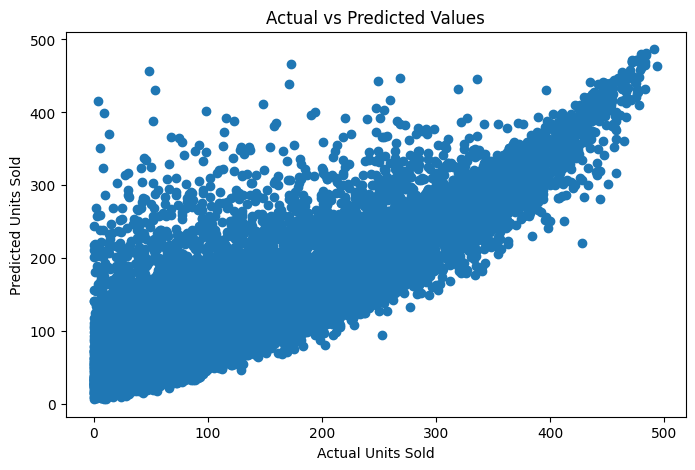

In [42]:
# Actual vs Predicted

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")

plt.title("Actual vs Predicted Values")

plt.show()

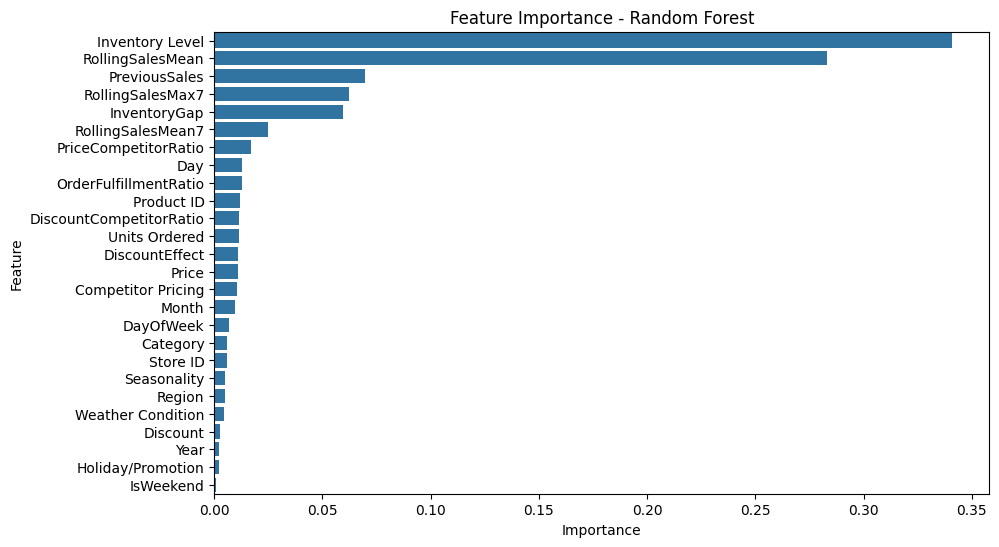

In [43]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

### Observation

Feature importance analysis helps identify which variables have the strongest influence on product demand prediction. This supports better retail decision-making and forecasting interpretation.

## XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is an advanced ensemble Machine Learning algorithm known for its high prediction accuracy and efficiency.

It improves model performance by combining multiple weak learners and minimizing prediction errors through boosting techniques.

In this project, XGBoost is used to improve retail demand forecasting performance and compare results with the Random Forest model.

In [44]:
# Install XGBoost

!pip install xgboost

In [45]:
from xgboost import XGBRegressor

In [46]:
# Initialize XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [47]:
# Predictions

xgb_predictions = xgb_model.predict(X_test)

xgb_predictions[:10]

array([ 79.947235, 170.00829 ,  92.910805, 168.24165 ,  53.004597,
        23.926598,  45.77947 ,  84.94899 , 223.35938 ,  42.20707 ],
      dtype=float32)

## Model Evaluation

The XGBoost model performance is evaluated using regression metrics to assess prediction quality and compare performance with the Random Forest model.

Evaluation Metrics:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [48]:
# Evaluation Metrics

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Performance")
print("------------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R² Score:", xgb_r2)

XGBoost Performance
------------------------
MAE : 43.85745620727539
RMSE: 58.403685487438416
R² Score: 0.7149806022644043


## Model Comparison

Different Machine Learning models were evaluated to identify the best-performing forecasting approach for retail demand prediction.

## Progress Summary

The model performance improved significantly after feature engineering. Advanced retail-based features such as previous sales, rolling sales average, price competition ratio, and discount impact helped improve forecasting accuracy.

Among the evaluated models, Random Forest achieved the best performance with an R² score of approximately 0.61.

# Deep Learning Model - LSTM

LSTM (Long Short-Term Memory) is a specialized Recurrent Neural Network (RNN) used for time-series forecasting. In this project, LSTM is implemented to forecast future retail demand using historical sales patterns.

In [49]:
df['RollingSalesStd'] = (
    df.groupby('Product ID')['Units Sold']
    .transform(
        lambda x: x.rolling(
            window=7,
            min_periods=1
        ).std()
    )
)

df['RollingSalesStd'] = (
    df['RollingSalesStd']
    .fillna(0)
)

In [50]:
df['InventoryCoverage'] = (
    df['Inventory Level']
    /
    (df['RollingSalesMean'] + 1)
)

In [51]:
lstm_features = [
    'Units Sold',
    'Inventory Level',
    'Price',
    'Discount',
    'Competitor Pricing',
    'PreviousSales',
    'RollingSalesMean',
    'RollingSalesStd',
    'InventoryCoverage',
    'IsWeekend'
]

lstm_df = df[lstm_features]

lstm_df.head()

,Units Sold,Inventory Level,Price,Discount,Competitor Pricing,PreviousSales,RollingSalesMean,RollingSalesStd,InventoryCoverage,IsWeekend
0,127,231,33.50,20,29.69,107.0,127.0,0.0,1.804688,1
1,150,204,63.01,20,66.16,107.0,150.0,0.0,1.350993,1
2,65,102,27.99,10,31.32,107.0,65.0,0.0,1.545455,1
3,61,469,32.72,10,34.74,107.0,61.0,0.0,7.564516,1
4,14,166,73.64,0,68.95,107.0,14.0,0.0,11.066667,1


In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    lstm_df
)

scaled_data.shape

(73100, 10)

In [53]:
import numpy as np

X_lstm = []
y_lstm = []

window_size = 30

for i in range(window_size, len(scaled_data)):

    X_lstm.append(
        scaled_data[
            i-window_size:i
        ]
    )

    y_lstm.append(
        scaled_data[i, 0]
    )

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print(X_lstm.shape)
print(y_lstm.shape)

(73070, 30, 10)
(73070,)


In [54]:
split = int(
    len(X_lstm) * 0.8
)

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )
)

model.add(
    Dropout(0.2)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.2)
)

model.add(
    Dense(32)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [58]:
model.compile(optimizer='adam', loss='mean_squared_error')


history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


TypeError: Exception encountered when calling LSTM.call().

[1mExpected int32, but got None of type 'NoneType'.[0m

Arguments received by LSTM.call():
  • sequences=tf.Tensor(shape=(None, 30, 10), dtype=float32)
  • initial_state=None
  • mask=None
  • training=True

In [ ]:
pred_scaled = model.predict(
    X_test_lstm
)

457/457 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step


In [ ]:
dummy_pred = np.zeros(
    (
        len(pred_scaled),
        len(lstm_features)
    )
)

dummy_pred[:,0] = pred_scaled[:,0]

pred_actual = scaler.inverse_transform(
    dummy_pred
)[:,0]


dummy_actual = np.zeros(
    (
        len(y_test_lstm),
        len(lstm_features)
    )
)

dummy_actual[:,0] = y_test_lstm

actual_values = scaler.inverse_transform(
    dummy_actual
)[:,0]

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

lstm_mae = mean_absolute_error(
    actual_values,
    pred_actual
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        pred_actual
    )
)

lstm_r2 = r2_score(
    actual_values,
    pred_actual
)

print("LSTM Performance")
print("----------------")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R² Score:", lstm_r2)

LSTM Performance
----------------
MAE : 89.55749009947893
RMSE: 108.34542887867428
R² Score: -0.0017874957197154817


# CatBoost Regressor

CatBoost is a gradient boosting algorithm designed to handle categorical and tabular data efficiently. It reduces overfitting and often achieves strong performance on structured business datasets.

In this project, CatBoost is implemented to improve retail demand forecasting and compare its performance with Random Forest, XGBoost, and LSTM models.

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train
)

0:	learn: 105.7918705	total: 38.7ms	remaining: 19.3s
100:	learn: 62.1073612	total: 4.01s	remaining: 15.8s
200:	learn: 60.4034933	total: 6.87s	remaining: 10.2s
300:	learn: 59.0299055	total: 9.44s	remaining: 6.24s
400:	learn: 57.7875846	total: 12.3s	remaining: 3.03s
499:	learn: 56.6311252	total: 17.3s	remaining: 0us


CatBoostRegressor(depth=8, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
cat_predictions = cat_model.predict(
    X_test
)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

cat_mae = mean_absolute_error(
    y_test,
    cat_predictions
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        cat_predictions
    )
)

cat_r2 = r2_score(
    y_test,
    cat_predictions
)

print("CatBoost Performance")
print("---------------------")
print("MAE :", cat_mae)
print("RMSE:", cat_rmse)
print("R² Score:", cat_r2)

CatBoost Performance
---------------------
MAE : 52.07573219382613
RMSE: 67.47095498610719
R² Score: 0.619611307007806


In [ ]:
feature_importance_cat = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.feature_importances_
})

feature_importance_cat = feature_importance_cat.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_cat.head(15)

,Feature,Importance
20,RollingSalesMean,22.854289
4,Inventory Level,22.117573
27,RollingSalesMax7,9.324327
23,InventoryGap,9.193128
21,RollingSalesStd,6.946049
26,RollingSalesMean7,6.763677
22,InventoryCoverage,5.901485
19,PreviousSales,4.451637
0,Store ID,3.249250
1,Product ID,1.169481


In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'CatBoost',
        'LSTM'
    ],
    'R2 Score': [
        rf_r2,
        xgb_r2,
        cat_r2,
        lstm_r2
    ]
})

comparison

,Model,R2 Score
0,Random Forest,0.687474
1,XGBoost,0.693728
2,CatBoost,0.619611
3,LSTM,-0.001787


# Inventory Optimization Module

The inventory optimization module uses the predicted demand generated by the best-performing model (XGBoost) to identify inventory risks and recommend optimal stock levels for efficient retail management.

In [59]:
# Create Results DataFrame

results = X_test.copy()

results['ActualDemand'] = y_test.values

results['PredictedDemand'] = xgb_predictions

results.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales,RollingSalesMean,InventoryGap,DiscountCompetitorRatio,OrderFulfillmentRatio,RollingSalesMean7,RollingSalesMax7,ActualDemand,PredictedDemand
66135,1,15,1,3,311,77,81.92,15,3,1,84.44,2,2023,10,24,1,0,0.958801,1228.80,246.0,131.333333,65.0,0.175562,0.246795,155.571429,465.0,123,79.947235
43486,4,6,1,1,480,186,46.39,5,1,1,49.32,3,2023,3,11,5,1,0.921900,231.95,5.0,85.666667,475.0,0.099364,0.386694,166.142857,429.0,24,170.008286
34322,1,2,0,0,167,53,87.41,5,0,0,88.21,0,2022,12,10,5,1,0.979823,437.05,97.0,115.000000,70.0,0.056048,0.315476,100.428571,211.0,136,92.910805
34317,0,17,1,3,350,157,98.65,15,3,0,95.43,1,2022,12,10,5,1,1.023022,1479.75,14.0,106.333333,336.0,0.155553,0.447293,100.714286,200.0,105,168.241653
38631,1,11,3,1,145,145,10.04,20,3,0,13.01,3,2023,1,22,6,1,0.716631,200.80,378.0,156.000000,-233.0,1.427552,0.993151,144.285714,378.0,76,53.004597


## Stock Risk Detection

Products are classified into three categories:

- Understock
- Optimal
- Overstock

In [60]:
def stock_status(row):

    if row['Inventory Level'] < row['PredictedDemand']:
        return "Understock"

    elif row['Inventory Level'] > row['PredictedDemand'] * 1.5:
        return "Overstock"

    else:
        return "Optimal"

In [61]:
results['StockStatus'] = results.apply(
    stock_status,
    axis=1
)

results.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales,RollingSalesMean,InventoryGap,DiscountCompetitorRatio,OrderFulfillmentRatio,RollingSalesMean7,RollingSalesMax7,ActualDemand,PredictedDemand,StockStatus
66135,1,15,1,3,311,77,81.92,15,3,1,84.44,2,2023,10,24,1,0,0.958801,1228.80,246.0,131.333333,65.0,0.175562,0.246795,155.571429,465.0,123,79.947235,Overstock
43486,4,6,1,1,480,186,46.39,5,1,1,49.32,3,2023,3,11,5,1,0.921900,231.95,5.0,85.666667,475.0,0.099364,0.386694,166.142857,429.0,24,170.008286,Overstock
34322,1,2,0,0,167,53,87.41,5,0,0,88.21,0,2022,12,10,5,1,0.979823,437.05,97.0,115.000000,70.0,0.056048,0.315476,100.428571,211.0,136,92.910805,Overstock
34317,0,17,1,3,350,157,98.65,15,3,0,95.43,1,2022,12,10,5,1,1.023022,1479.75,14.0,106.333333,336.0,0.155553,0.447293,100.714286,200.0,105,168.241653,Overstock
38631,1,11,3,1,145,145,10.04,20,3,0,13.01,3,2023,1,22,6,1,0.716631,200.80,378.0,156.000000,-233.0,1.427552,0.993151,144.285714,378.0,76,53.004597,Overstock


In [62]:
results['RecommendedStock'] = (
    results['PredictedDemand'] * 1.20
).round()

results.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Year,Month,Day,DayOfWeek,IsWeekend,PriceCompetitorRatio,DiscountEffect,PreviousSales,RollingSalesMean,InventoryGap,DiscountCompetitorRatio,OrderFulfillmentRatio,RollingSalesMean7,RollingSalesMax7,ActualDemand,PredictedDemand,StockStatus,RecommendedStock
66135,1,15,1,3,311,77,81.92,15,3,1,84.44,2,2023,10,24,1,0,0.958801,1228.80,246.0,131.333333,65.0,0.175562,0.246795,155.571429,465.0,123,79.947235,Overstock,96.0
43486,4,6,1,1,480,186,46.39,5,1,1,49.32,3,2023,3,11,5,1,0.921900,231.95,5.0,85.666667,475.0,0.099364,0.386694,166.142857,429.0,24,170.008286,Overstock,204.0
34322,1,2,0,0,167,53,87.41,5,0,0,88.21,0,2022,12,10,5,1,0.979823,437.05,97.0,115.000000,70.0,0.056048,0.315476,100.428571,211.0,136,92.910805,Overstock,111.0
34317,0,17,1,3,350,157,98.65,15,3,0,95.43,1,2022,12,10,5,1,1.023022,1479.75,14.0,106.333333,336.0,0.155553,0.447293,100.714286,200.0,105,168.241653,Overstock,202.0
38631,1,11,3,1,145,145,10.04,20,3,0,13.01,3,2023,1,22,6,1,0.716631,200.80,378.0,156.000000,-233.0,1.427552,0.993151,144.285714,378.0,76,53.004597,Overstock,64.0


In [63]:
results['StockStatus'].value_counts()

,count
StockStatus,
Overstock,12137
Optimal,2483


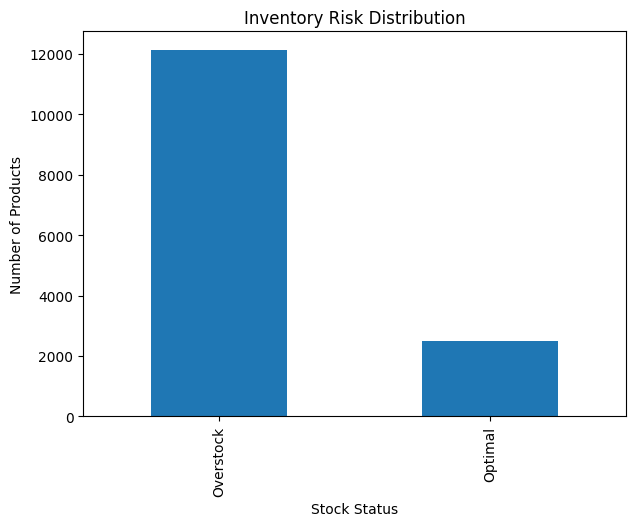

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

results['StockStatus'].value_counts().plot(
    kind='bar'
)

plt.title("Inventory Risk Distribution")

plt.xlabel("Stock Status")

plt.ylabel("Number of Products")

plt.show()

In [66]:
critical_products = results[
    results['StockStatus']=="Understock"
]

critical_products[
    [
        'Inventory Level',
        'PredictedDemand',
        'RecommendedStock'
    ]
].head(10)

,Inventory Level,PredictedDemand,RecommendedStock
